# 1. 필요 모듈 import


In [24]:
import os
import sys
import time
import glob
import csv
import json
import re
import urllib.parse
import urllib.request
from datetime import datetime
from collections import Counter

import pandas as pd
import emoji
from hanspell import spell_checker
from konlpy.tag import Okt
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.common.exceptions import UnexpectedAlertPresentException, NoAlertPresentException
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from wordcloud import WordCloud
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

In [25]:
# 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"  # 시스템 환경에 맞게 경로 조정
fontprop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fontprop.get_name()
plt.rcParams['axes.unicode_minus'] = False
input_folder = "./merged_teams/" #"C:/Users/magpi/Desktop/2025/텍스트데이터분석/merged_teams"

# 날짜 및 API 설정
today = datetime.today().strftime('%Y-%m-%d')  # 오늘 날짜 - 데이터 수집 당일 날짜
client_id = 'None'                             # 네이버 API ID
client_secret = 'None'                         # 네이버 API Secret


# 2. Data crawling

In [ ]:
# 크롬 드라이버 설정
driver = webdriver.Chrome()
driver.implicitly_wait(3)

# 블로그 본문 내용 크롤링 함수
def extract_naver_blog_post_selenium(url):
    try:
        driver.get(url)
        time.sleep(2)

        # 프레임 전환 시도 (네이버 블로그는 본문이 iframe 내부에 있을 수 있음)
        try:
            driver.switch_to.frame(0)
        except:
            pass

        # 제목 추출 
        try:
            title_elem = driver.find_elements(By.CLASS_NAME, 'pcol1')
            title = title_elem[0].text if title_elem else None
        except:
            title = None

        # 본문 내용 추출 
        try:
            body_elem = driver.find_elements(By.CLASS_NAME, 'se-main-container')
            body_text = body_elem[0].text.replace('\n', '') if body_elem else ""
        except:
            body_text = ""

        return title, body_text

    # 경고창이 뜨는 경우
    except UnexpectedAlertPresentException:
        try:
            alert = driver.switch_to.alert
            alert.accept()
        except NoAlertPresentException:
            pass
        return None, ""
    except Exception:
        return None, ""

# 블로그 검색 결과를 수집하고 본문 내용을 크롤링하는 메인 함수
def fetch_blog_links(team_name):
    encoded_query = urllib.parse.quote(team_name)
    team_data = []

    # HTML 태그 제거를 위한 정규표현식 패턴
    tag_pattern = re.compile('<[^>]+>')

    # 파일 이름에 쓸 수 있도록 안전한 팀 이름으로 변환
    safe_team_name = re.sub(r'[^가-힣a-zA-Z0-9 ]', '', team_name).replace(' ', '_')
    csv_filename = f'{safe_team_name}_blog_data_{today}.csv'

    # 이미 수집된 링크를 확인하여 중복 제거
    existing_links = set()
    for file in glob.glob(f'{safe_team_name}_blog_data_*.csv'):
        if today in file:
            continue
        try:
            df_old = pd.read_csv(file)
            existing_links.update(df_old['link'].dropna().unique())
        except:
            continue

    # 네이버 블로그 검색 API를 통해 1000개의 결과를 100개씩 요청
    for start in range(1, 1001, 100):
        url = f"https://openapi.naver.com/v1/search/blog?query={encoded_query}&display=100&start={start}&sort=sim"
        request = urllib.request.Request(url)
        request.add_header("X-Naver-Client-Id", client_id)
        request.add_header("X-Naver-Client-Secret", client_secret)

        try:
            response = urllib.request.urlopen(request)
            rescode = response.getcode()
        except:
            break

        # API 호출 성공 시 결과 처리
        if rescode == 200:
            try:
                response_body = response.read()
                result = json.loads(response_body.decode('utf-8'))['items']
            except:
                break

            for item in result:
                link = item['link']
                if link in existing_links:
                    continue

                # 제목 및 설명에서 HTML 태그 제거
                raw_title = re.sub(tag_pattern, '', item['title'])
                raw_description = re.sub(tag_pattern, '', item['description'])
                postdate = item.get('postdate', '')
                bloggername = item.get('bloggername', '')

                # 블로그 본문 크롤링
                title, content = extract_naver_blog_post_selenium(link)
                time.sleep(1.0)

                # 결과 리스트에 추가
                team_data.append({
                    'team': team_name,
                    'bloggername': bloggername,
                    'title': title or raw_title,
                    'description': raw_description,
                    'link': link,
                    'postdate': postdate,
                    'content': content
                })

                existing_links.add(link)

            time.sleep(1.5)
        else:
            break

    if team_data:
        try:
            df = pd.DataFrame(team_data)
            df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
        except:
            pass

# 수집 대상 팀 리스트
teams = ['KIA 타이거즈', '롯데 자이언츠', 'SSG 랜더스', '한화 이글스', 'LG 트윈스']

# 각 팀에 대해 데이터 수집 실행
for team in teams:
    fetch_blog_links(team)

# 크롬 드라이버 종료
driver.quit()

# 3. Stopwords

In [26]:
stopwords_list = [

    # 구단명 (영문, 한글, 병기)
    'KIA', '기아', '타이거즈',
    '롯데', '자이언츠',
    'SSG', '쓱', '랜더스', '랜더',
    '한화', '이글스', '한화이글스',
    'LG', '엘지', '트윈스',
    '두산', '베어스', '두산베어스',
    '삼성', '라이온즈', '삼성라이온즈',
    '키움', '히어로즈', '키움히어로즈',
    'NC', '엔씨', '다이노스', '엔씨다이노스',
    'KT', '케이티', '위즈', '케이티위즈',

    # 경기 관련 일반 단어
    '경기', '시즌', '선수', '팀', '팬', '상대', '점수', '승리', '패배', '응원', '한국', '시리즈',
    '티켓', '유니폼', '홈', '원정', '타자', '투수', '포수', '득점', '실점', '중계', '필드', '야구장',
    '예매', '구매', '가격', '인천코크', '가지보이', '경기장', '결과', '경기력', '리그', '매치', '스코어',
    '라운드', '야구', '선발', '황영', '묵', '상황', '구단', '진행', '활약', '기대', '대결',

    # 날짜 및 시간 표현
    '오늘', '어제', '내일', '이번', '지난', '다음', '주말', '평일', '올해', '지금',
    '년', '월', '일', '시간', '분', '오전', '오후', '최근', '현재', '요즘',

    # 블로그/플랫폼 특유 단어
    '사진', '영상', '댓글', '좋아요', '조회수', '블로그', '포스팅', '생각', '기록',
    '작성자', '공유', '링크', '페이지', '내용', '클릭', '공지', '이벤트', '일정',

    # 잔여 조사 및 의미 없는 어절
    '것', '거', '좀', '등', '수', '때', '듯', '건', '게', '더', '바로', '우리', '가장', '모두',
    '정도', '시작', '정말', '통해', '그', '저', '이', '나', '도', '까지', '마다', '처럼', '에서',
    '부터', '진짜', '이제', '확인', '때문', '만큼', '모습', '하나', '접기', '다시', '자리',
    '좌석', '직관', '인석', '화생', '이후', '사람'
]

with open("stopwords.txt", "w", encoding="utf-8") as f:
    for word in stopwords_list:
        f.write(word + "\n")

# 4. 데이터 전처리

In [27]:
# 형태소 분석기 초기화
okt = Okt()

# 1. 불용어 불러오기
def load_stopwords(filepath="stopwords.txt"):
    with open(filepath, "r", encoding="utf-8") as f:
        return [line.strip() for line in f.readlines()]
stopwords = load_stopwords("stopwords.txt")

# 2. 맞춤법 교정 함수
def spell_check_long_text(text):
    sentences = []
    for i in range(0, len(text), 500):
        chunk = text[i:i+500]
        try:
            checked = spell_checker.check(chunk).checked
            sentences.append(checked)
        except:
            sentences.append(chunk)
    return ''.join(sentences)

# 3. 텍스트 전처리 및 형태소 분석 기반 불용어 제거
def preprocess_for_wordcloud(text, stopwords):
    if pd.isna(text):
        return ""

    # 줄바꿈 및 공백 정리
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text)

    # 이모지 제거
    text = emoji.replace_emoji(text, replace='')

    # HTML 태그 제거
    text = re.sub(r'<[^>]+>', '', text)

    # 날짜 및 시간 표현 제거
    text = re.sub(r'\d{4}[-./년\s]?\d{1,2}[-./월\s]?\d{1,2}[일\s]?', '', text)
    text = re.sub(r'\d{1,2}[-./]\d{1,2}', '', text)
    text = re.sub(r'\d+일|\d+월|\d+년|\d+분|\d+초|\d+시', '', text)

    # 특수문자 제거
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)

    # 맞춤법 교정
    try:
        text = spell_check_long_text(text)
    except:
        pass

    # 형태소 분석 후 명사만 추출하고 불용어 제거
    tokens = okt.pos(text, stem=True)
    nouns = [word for word, pos in tokens if pos == 'Noun' and word not in stopwords and len(word) > 1]
    return ' '.join(nouns)

In [28]:
# 전체 CSV 파일 처리
files = glob.glob("merged_teams/*_merged.csv")

for file in files:
    df = pd.read_csv(file)
    if 'content' not in df.columns:
        continue  # content 컬럼 없으면 건너뜀

    df['processed_content'] = df['content'] \
        .astype(str) \
        .apply(lambda x: preprocess_for_wordcloud(x, stopwords))

    output_file = file.replace("_merged.csv", "_processed.csv")
    df.to_csv(output_file, index=False, encoding='utf-8-sig')

# 5. Wordcloud


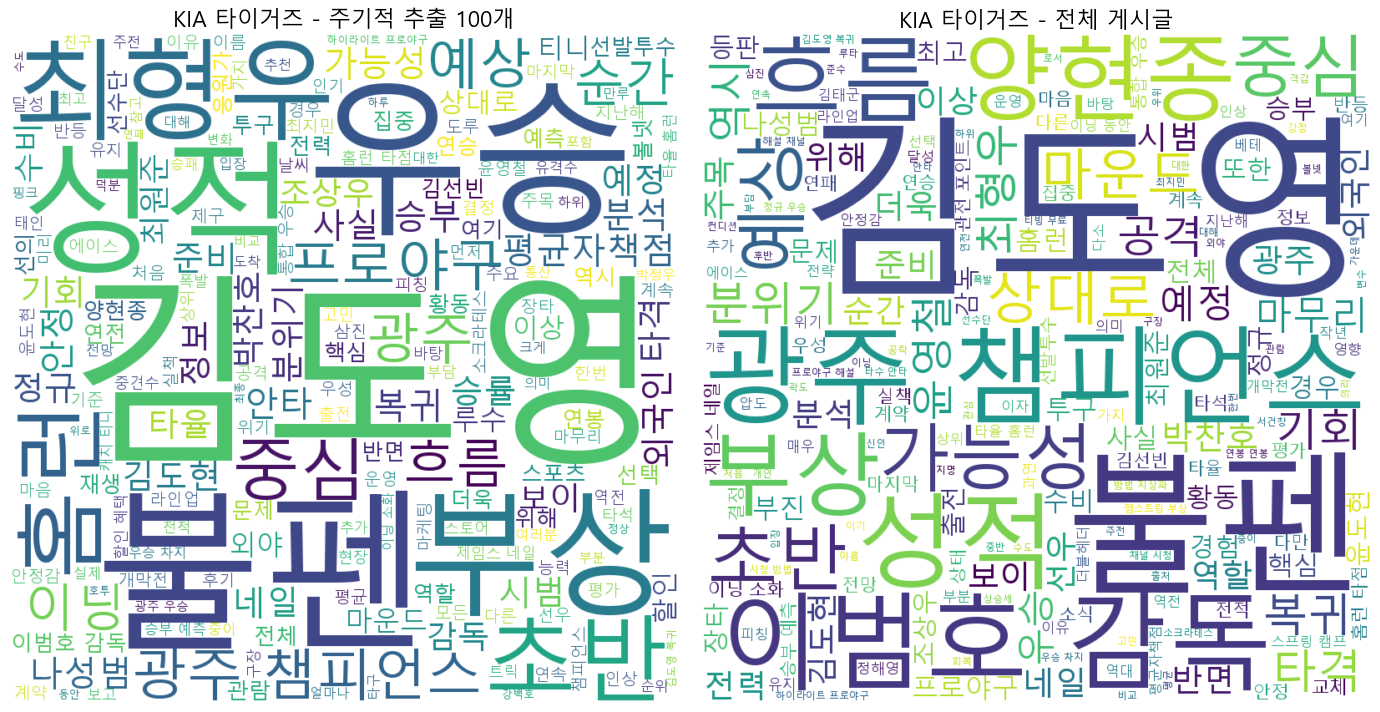

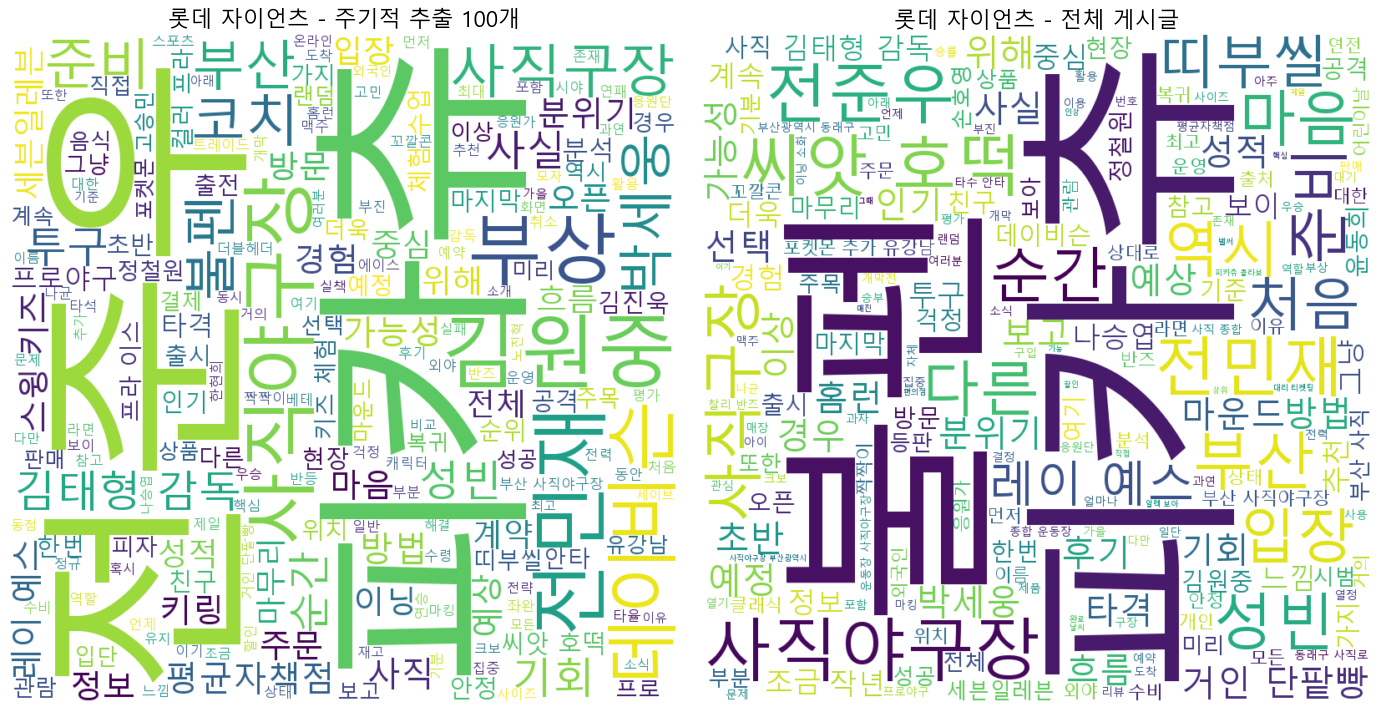

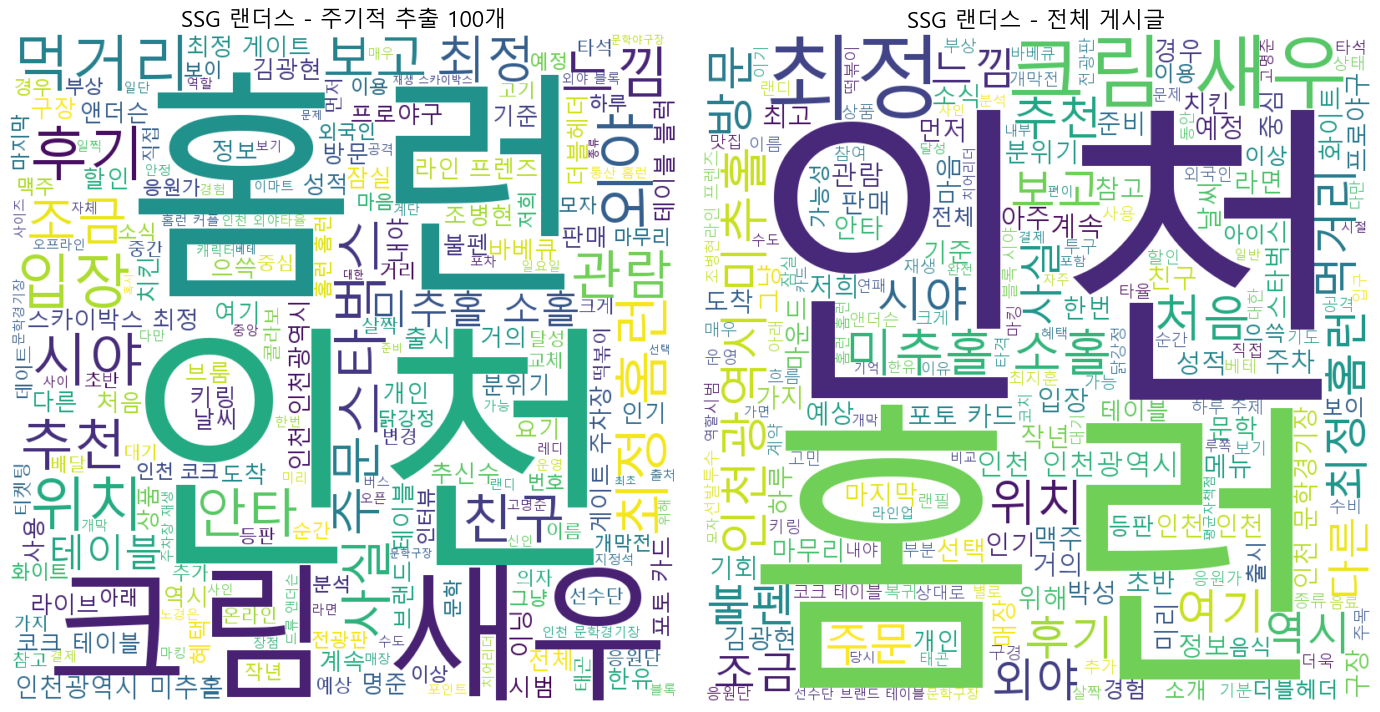

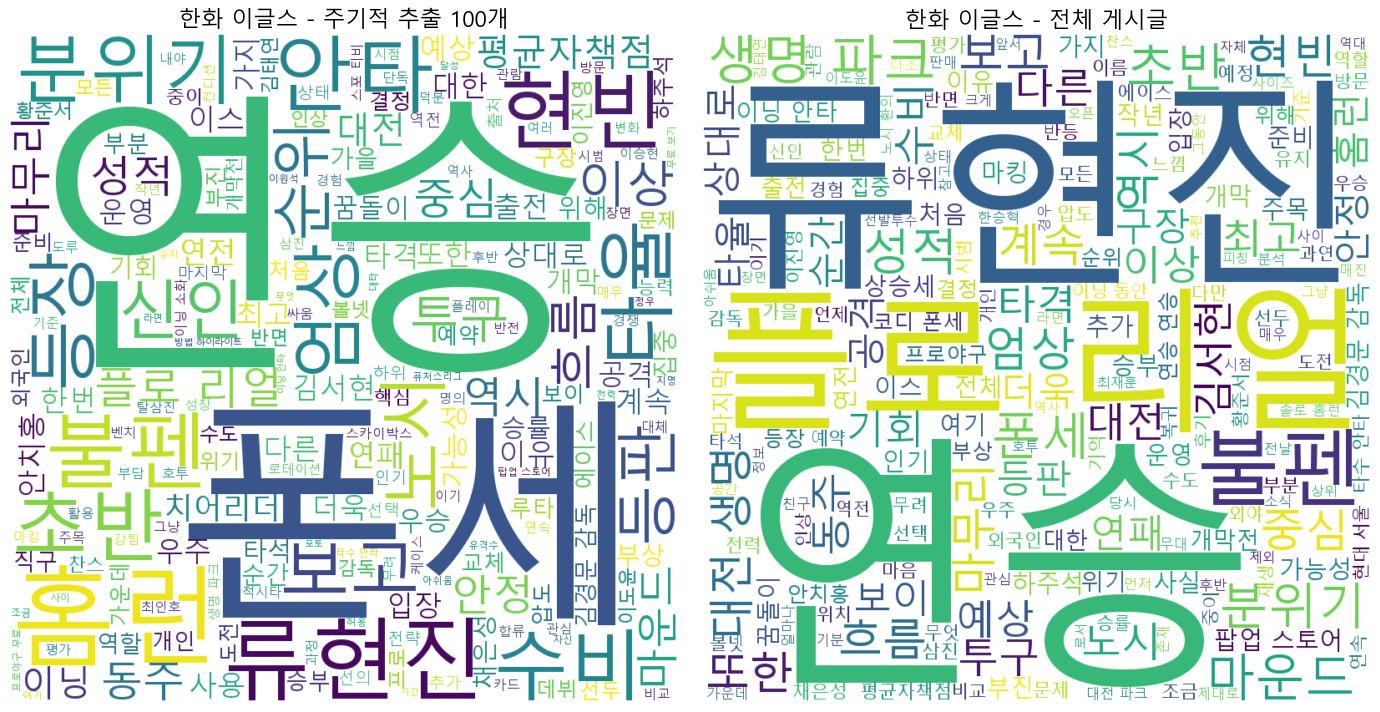

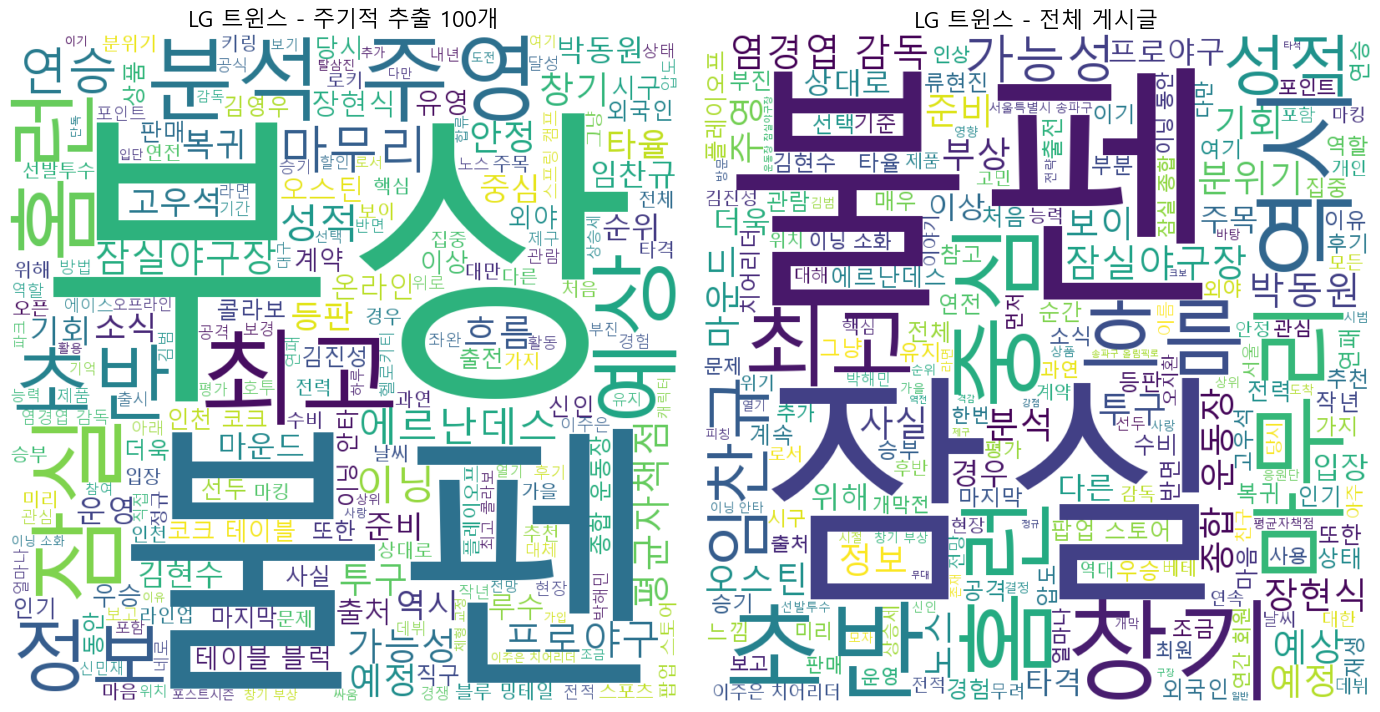

In [29]:
# 팀 이름과 파일명 매핑
team_to_filename = {
    "KIA 타이거즈": "KIA_타이거즈",
    "롯데 자이언츠": "롯데_자이언츠",
    "SSG 랜더스": "SSG_랜더스",
    "한화 이글스": "한화_이글스",
    "LG 트윈스": "LG_트윈스"
}

teams = list(team_to_filename.keys())

for team in teams:
    safe_name = team_to_filename[team]
    file_path = os.path.join(input_folder, f'{safe_name}_processed.csv')
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path, encoding='utf-8-sig')
    if 'processed_content' not in df.columns or 'postdate' not in df.columns:
        continue

    # 날짜 형식으로 변환 후 정렬
    df['date'] = pd.to_datetime(df['postdate'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['date']).sort_values(by='date').reset_index(drop=True)

    # 전체 중에서 주기적으로 100개 추출
    total = len(df)
    if total < 100:
        sampled_df = df
    else:
        indices = sorted({min(int(i * total / 100), total - 1) for i in range(100)})
        sampled_df = df.iloc[indices]

    # 텍스트 합치기
    text_sampled = ' '.join(sampled_df['processed_content'].fillna(''))
    text_all    = ' '.join(df['processed_content'].fillna(''))
    if not text_sampled.strip() and not text_all.strip():
        continue

    # 워드클라우드 생성
    wc_sampled = WordCloud(font_path=font_path, background_color='white', width=800, height=800)\
        .generate(text_sampled)
    wc_all     = WordCloud(font_path=font_path, background_color='white', width=800, height=800)\
        .generate(text_all)

    # 시각화
    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(wc_sampled, interpolation='bilinear')
    plt.title(f"{team} - 주기적 추출 100개", fontsize=16)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(wc_all, interpolation='bilinear')
    plt.title(f"{team} - 전체 게시글", fontsize=16)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## (+) 날짜 별로 수집했던 데이터를 최종 분석에 사용하기 위해 병합한 코드

In [ ]:
# 분석할 구단
target_teams = ['KIA 타이거즈', '롯데 자이언츠', 'SSG 랜더스', '한화 이글스', 'LG 트윈스']

# 구단 이름을 안전한 파일명으로 변환
team_to_filename = {
    team: re.sub(r'[^가-힣a-zA-Z0-9 ]', '', team).replace(' ', '_')
    for team in target_teams
}

# 병합된 파일 저장 경로
output_folder = "./merged_teams/"
os.makedirs(output_folder, exist_ok=True)

for team in target_teams:
    safe_name = team_to_filename[team]
    files = glob.glob(f"{safe_name}_blog_data_2025-*-*.csv")
    if not files:
        continue  # 해당 파일이 없으면 다음 팀으로

    # CSV 파일 병합 및 저장
    df_list = [pd.read_csv(file) for file in files]
    merged_df = pd.concat(df_list, ignore_index=True)
    merged_filename = os.path.join(output_folder, f"{safe_name}_merged.csv")
    merged_df.to_csv(merged_filename, index=False, encoding='utf-8-sig')